In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("manonstr/tipe-webscraping")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 1.12G/1.12G [00:11<00:00, 103MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/manonstr/tipe-webscraping/versions/12
Contents of base_path (/root/.cache/kagglehub/datasets/manonstr/tipe-webscraping/versions):
['12']
Contents of path (/root/.cache/kagglehub/datasets/manonstr/tipe-webscraping/versions/12):
['1024+']


Checking for image folders in: /root/.cache/kagglehub/datasets/manonstr/tipe-webscraping/versions/12/1024+
Contents of /root/.cache/kagglehub/datasets/manonstr/tipe-webscraping/versions/12/1024+: ['entrainement', 'test']
Searching for images in: /root/.cache/kagglehub/datasets/manonstr/tipe-webscraping/versions/12/1024+/entrainement
Searching for images in: /root/.cache/kagglehub/datasets/manonstr/tipe-webscraping/versions/12/1024+/test

Found 7190 image files in total. Displaying a few samples:


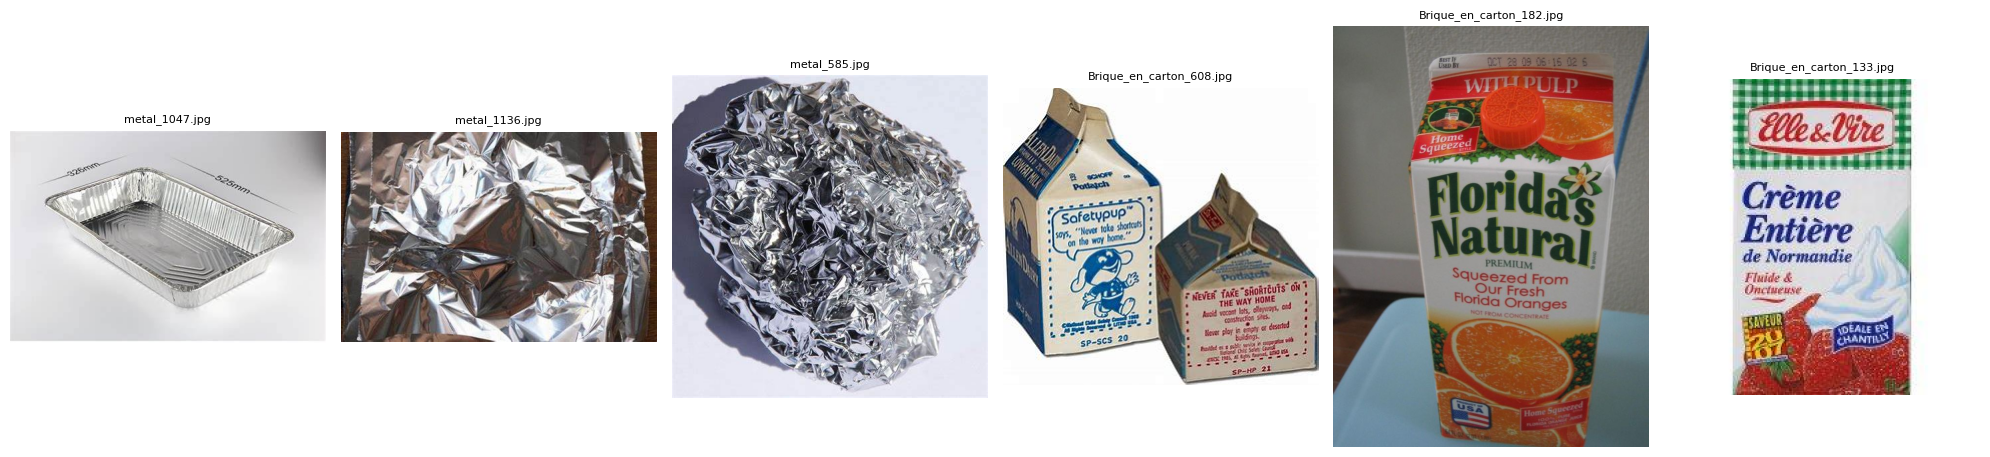

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Define the base directory where images are expected (inside '1024+')
image_root_dir = os.path.join(path, '1024+')

print(f"Checking for image folders in: {image_root_dir}")
if not os.path.exists(image_root_dir):
    print(f"Error: Directory '{image_root_dir}' not found. Please ensure the dataset structure is as expected.")
else:
    print(f"Contents of {image_root_dir}: {os.listdir(image_root_dir)}")

    # Collect all image files from 'entrainement' and 'test' subfolders
    all_image_paths = []
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')

    subfolders_to_check = ['entrainement', 'test']

    for subfolder_name in subfolders_to_check:
        current_search_path = os.path.join(image_root_dir, subfolder_name)
        if os.path.isdir(current_search_path):
            print(f"Searching for images in: {current_search_path}")
            for root, dirs, files in os.walk(current_search_path):
                for file in files:
                    if file.lower().endswith(image_extensions):
                        all_image_paths.append(os.path.join(root, file))
        else:
            print(f"Warning: '{subfolder_name}' directory not found at {current_search_path}")

    if all_image_paths:
        print(f"\nFound {len(all_image_paths)} image files in total. Displaying a few samples:")
        # Select a few distinct samples to display (e.g., from beginning and middle)
        samples_to_display = all_image_paths[:min(len(all_image_paths), 3)]
        if len(all_image_paths) > 3:
            samples_to_display.extend(all_image_paths[len(all_image_paths)//2 : min(len(all_image_paths)//2 + 3, len(all_image_paths))])
        samples_to_display = list(dict.fromkeys(samples_to_display)) # Remove duplicates while preserving order
        samples_to_display = samples_to_display[:min(len(samples_to_display), 6)] # Ensure max 6 samples

        if samples_to_display:
            fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
            if len(samples_to_display) == 1:
                axes = [axes] # Make it iterable for consistency

            for i, img_path in enumerate(samples_to_display):
                try:
                    img = Image.open(img_path)
                    axes[i].imshow(img)
                    axes[i].set_title(os.path.basename(img_path), fontsize=8)
                    axes[i].axis('off')
                except Exception as e:
                    axes[i].set_title(f"Error loading {os.path.basename(img_path)}", fontsize=8)
                    axes[i].axis('off')
                    print(f"Error loading image {img_path}: {e}")
            plt.tight_layout()
            plt.show()
        else:
            print("No unique image samples selected for display.")
    else:
        print("\nNo common image files (png, jpg, jpeg, gif, bmp) found in the specified 'entrainement' or 'test' directories.")

### GPU Check

First, let's verify if a GPU is available and being used by TensorFlow.

In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

if tf.test.is_gpu_available():
    print("GPU is available for training!")
    print("GPU device name:", tf.config.experimental.list_physical_devices('GPU'))
else:
    print("No GPU available. Training will run on CPU.")

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


TensorFlow version: 2.20.0
Num GPUs Available:  1
GPU is available for training!
GPU device name: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### MobileNet Model Building and Training

Now, let's prepare the image data and build a MobileNetV2 model for image classification. We'll use a pre-trained MobileNetV2 as a base and add a custom classification head.

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Define image parameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Define the base directory for images, which is '1024+' under the downloaded path
image_root_dir = os.path.join(path, '1024+')

# Use image_dataset_from_directory to load the 'entrainement' and 'test' folders
# We'll need to specify these subdirectories explicitly if image_root_dir itself is not the parent of class folders
# Assuming 'entrainement' and 'test' contain class-specific subfolders directly

train_dir = os.path.join(image_root_dir, 'entrainement')
test_dir = os.path.join(image_root_dir, 'test')

# Create training dataset
train_dataset = image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Create validation/test dataset
validation_dataset = image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Get class names
class_names = train_dataset.class_names
num_classes = len(class_names)
print(f"Found {num_classes} classes: {class_names}")

# Configure dataset for performance
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)

# Load MobileNetV2 base model (pre-trained on ImageNet)
base_model = MobileNetV2(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
                         include_top=False,
                         weights='imagenet')

# Freeze the base model to use its pre-trained features
base_model.trainable = False

# Add a custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x) # Additional dense layer
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# Train the model
EPOCHS = 10 # You can adjust the number of epochs
history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=validation_dataset
)

Found 7033 files belonging to 6 classes.
Found 157 files belonging to 6 classes.
Found 6 classes: ['Bouteille_plastique', 'Brique_en_carton', 'Emballage_metallique', 'Ordure_m∩┐╜nag∩┐╜re', 'Papier_Carton', 'Verre']
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 86s 303ms/step - accuracy: 0.6248 - loss: 0.9785 - val_accuracy: 0.3631 - val_loss: 2.0356
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.7579 - loss: 0.6660 - val_accuracy: 0.3631 - val_loss: 2.0757
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.7999 - loss: 0.5571 - val_accuracy: 0.3631 - val_loss: 2.1347
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8233 - loss: 0.4861 - val_accuracy: 0.3949 - val_loss: 2.1493
Epoch 5/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.8496 - loss: 0.4281 - val_accuracy: 0.3758 - val_loss: 2.1971
Epoch 6/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8649 - loss: 0.3792 - val_accuracy: 0.3758 - val_loss: 2.3324
Epoch 7/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8803 - loss: 0.3379 - val_accuracy: 0.3631 - val_loss: 2.4778
Epoch 8/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.8944 - loss: 0.3043 - val_ac

### Summarize Training Results

After training, let's evaluate the model on the test set to see its performance and display a summary of the model architecture.

In [ ]:
# Print model summary again (if needed, already done above)
# model.summary()

# Evaluate the model on the validation dataset
print("\nEvaluating model on the validation dataset...")
loss, accuracy = model.evaluate(validation_dataset)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")


Evaluating model on the validation dataset...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3949 - loss: 2.8023
Validation Loss: 2.8023
Validation Accuracy: 0.3949


### Display Training Plots

Visualize the training and validation accuracy and loss over epochs to understand the model's learning process.

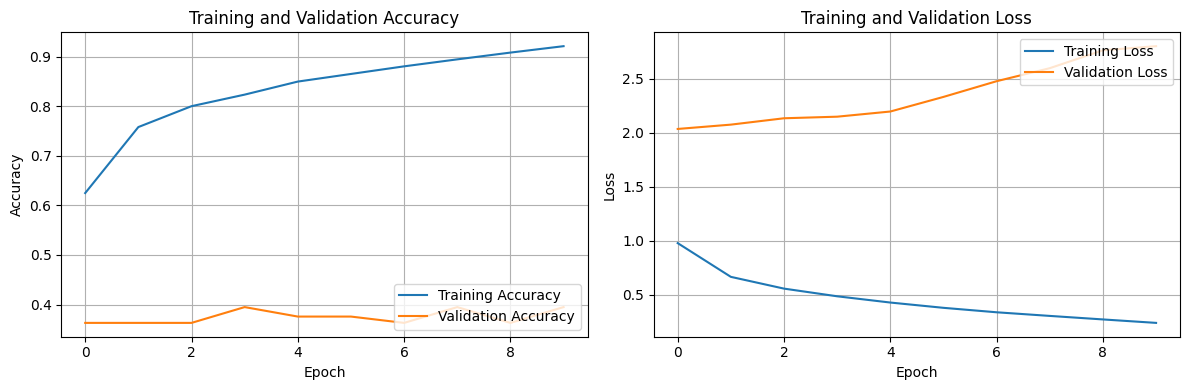

In [ ]:
import matplotlib.pyplot as plt

# Get training history data
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 4))

# Plot training and validation accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.tight_layout()
plt.show()